# compare ETCCDI indices from CanEsm
Here we test the homemade ETCCDI index functions

# Imports and setup

In [1]:
%load_ext autoreload
%autoreload 2

# ---
# logging setup
# ---
import logging
from general_backend.logging.setup_logging import (
    configure_package_logger as configure_general_backend_logger,
 )
from pyClimExtremes.logging.setup_logging import (
    configure_package_logger as configure_pyclimextremes_logger,
 )

# Add handlers so INFO logs are visible in the notebook for both packages
configure_general_backend_logger(
    level=logging.INFO,
    propagate=True,
    add_handler=True,
    fmt='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
 )
configure_pyclimextremes_logger(
    level=logging.DEBUG,
    propagate=True,
    add_handler=True,
    fmt='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
 )

# ---
# imports
# ---
import subprocess
from pathlib import Path

import netCDF4
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

from pyClimExtremes.indices import get_creatable_indices
from pyClimExtremes.scripts.compute_indices import compute_indices

# ---
# paths
# ---
raw_data_path = Path('/nird/datalake/NS9560K/johannef/test_ETCCDI_calc/raw_input')
refdir_path = Path('/nird/datalake/NS9560K/johannef/test_ETCCDI_calc/ETCCDI_output')
savepath = Path('/nird/datalake/NS9560K/johannef/test_ETCCDI_calc/homemade_output')

2026-04-09 17:24:02,054 - pyClimExtremes.indices.registry - DEBUG - Registered index 'fdETCCDI'
2026-04-09 17:24:02,055 - pyClimExtremes.indices.registry - DEBUG - Registered index 'suETCCDI'
2026-04-09 17:24:02,055 - pyClimExtremes.indices.registry - DEBUG - Registered index 'idETCCDI'
2026-04-09 17:24:02,056 - pyClimExtremes.indices.registry - DEBUG - Registered index 'trETCCDI'
2026-04-09 17:24:02,056 - pyClimExtremes.indices.registry - DEBUG - Registered index 'gslETCCDI'
2026-04-09 17:24:02,056 - pyClimExtremes.indices.registry - DEBUG - Registered index 'txxETCCDI'
2026-04-09 17:24:02,057 - pyClimExtremes.indices.registry - DEBUG - Registered index 'txnETCCDI'
2026-04-09 17:24:02,057 - pyClimExtremes.indices.registry - DEBUG - Registered index 'tnxETCCDI'
2026-04-09 17:24:02,058 - pyClimExtremes.indices.registry - DEBUG - Registered index 'tnnETCCDI'
2026-04-09 17:24:02,058 - pyClimExtremes.indices.registry - DEBUG - Registered index 'dtrETCCDI'
2026-04-09 17:24:02,060 - pyClimEx

# Reference data

In [2]:
input_files = list(raw_data_path.glob('*CanESM5*.nc'))
for file in input_files:
    print(file.name)

tas_day_CanESM5_ssp585_r1i1p1f1_gn_21010101-21801231.nc
pr_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
tas_day_CanESM5_ssp585_r1i1p1f1_gn_20150101-21001231.nc
tasmax_day_CanESM5_ssp585_r1i1p1f1_gn_20150101-21801231.nc
tas_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
pr_day_CanESM5_ssp585_r1i1p1f1_gn_20150101-21001231.nc
tasmax_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc
tasmin_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc


In [3]:
run_process = False
if not run_process:
    print("Skipping unit conversion process.")
else:
    def convert_K_to_C(ds):
        for data_var in [var for var in ds.data_vars if 'tas' in var]:
            if ds[data_var].units == 'K':
                ds[data_var] = ds[data_var] - 273.15
                ds[data_var].attrs['units'] = 'deg_C'
        return ds

    def convert_pr_units(ds):
        for data_var in [var for var in ds.data_vars if 'pr' in var]:
            if ds[data_var].units == 'kg m-2 s-1':
                ds[data_var] = ds[data_var] * 86400  # Convert to mm/day
                ds[data_var].attrs['units'] = 'mm/day'
        return ds

    fixed_input_path = Path('/nird/datalake/NS9560K/johannef/test_ETCCDI_calc/fixed_input')
    if not fixed_input_path.exists():
        fixed_input_path.mkdir(parents=True, exist_ok=True)

    for indx, file in enumerate(input_files):
        ds = xr.open_dataset(file)
        if not any(ds[var].units == 'K' for var in ds.data_vars if 'tas' in var):
            print(f'{file.name}: No K to C conversion needed.')
            ds.close()
            continue  # No conversion needed
        ds_converted = convert_K_to_C(ds)
        new_path = fixed_input_path / file.name
        ds_converted.to_netcdf(new_path)
        ds.close()
        ds_converted.close()
        print(f'{file.name}: Converted K to C and saved to {new_path}')

        input_files[indx] = new_path  # Update the list to point to the fixed files
    for indx, file in enumerate(input_files):
        ds = xr.open_dataset(file)
        if not any(ds[var].units == 'kg m-2 s-1' for var in ds.data_vars if 'pr' in var):
            print(f'{file.name}: No pr unit conversion needed.')
            ds.close()
            continue  # No conversion needed
        ds_converted = convert_pr_units(ds)
        new_path = fixed_input_path / file.name
        ds_converted.to_netcdf(new_path)
        ds.close()
        ds_converted.close()
        print(f'{file.name}: Converted pr units and saved to {new_path}')

        input_files[indx] = new_path  # Update the list to point to the fixed files

Skipping unit conversion process.


In [ ]:
new_files, skipped_files = compute_indices(
    indices='gslETCCDI',
    compute_fq='yr',
    compute_backend='python',
    output_dir=savepath,
    output_file_template="cmip6",
    tasmax=Path('/nird/datalake/NS9560K/johannef/test_ETCCDI_calc/raw_input/tasmax_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc'),
    tasmin=Path('/nird/datalake/NS9560K/johannef/test_ETCCDI_calc/raw_input/tasmin_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc'),
    tas=Path('/nird/datalake/NS9560K/johannef/test_ETCCDI_calc/raw_input/tas_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc'),
    pr=None,
    overwrite=True,
)
print(new_files)

2026-04-09 17:24:02,232 - pyClimExtremes.indices.registry - DEBUG - Resolved indices to compute: [<class 'pyClimExtremes.indices.temperature_indices.GSLIndex'>]
2026-04-09 17:24:02,233 - pyClimExtremes.indices.registry - DEBUG - Resolved frequencies to compute: ['yr']
2026-04-09 17:24:02,233 - pyClimExtremes.scripts.compute_indices - DEBUG - Required input variables for requested indices: ['tas']
2026-04-09 17:24:02,254 - pyClimExtremes.io.data_wrapping - DEBUG - Opened DataWrapper for /nird/datalake/NS9560K/johannef/test_ETCCDI_calc/raw_input/tas_day_CanESM5_historical_r1i1p1f1_gn_18500101-20141231.nc


Checking for gslETCCDI
 * Checking dimensions...
    * Reference dimension lat: 64
    * Homemade dimension lat: 64
    * Reference dimension bnds: 2
    * Homemade dimension bnds: 2
    * Reference dimension lon: 128
    * Homemade dimension lon: 128
    * Reference dimension time: 165
    * Homemade dimension time: 165
 * Checking coordinates...
    * Coordinate lat matches.
    * Coordinate lon matches.
    * Coordinate time matches.


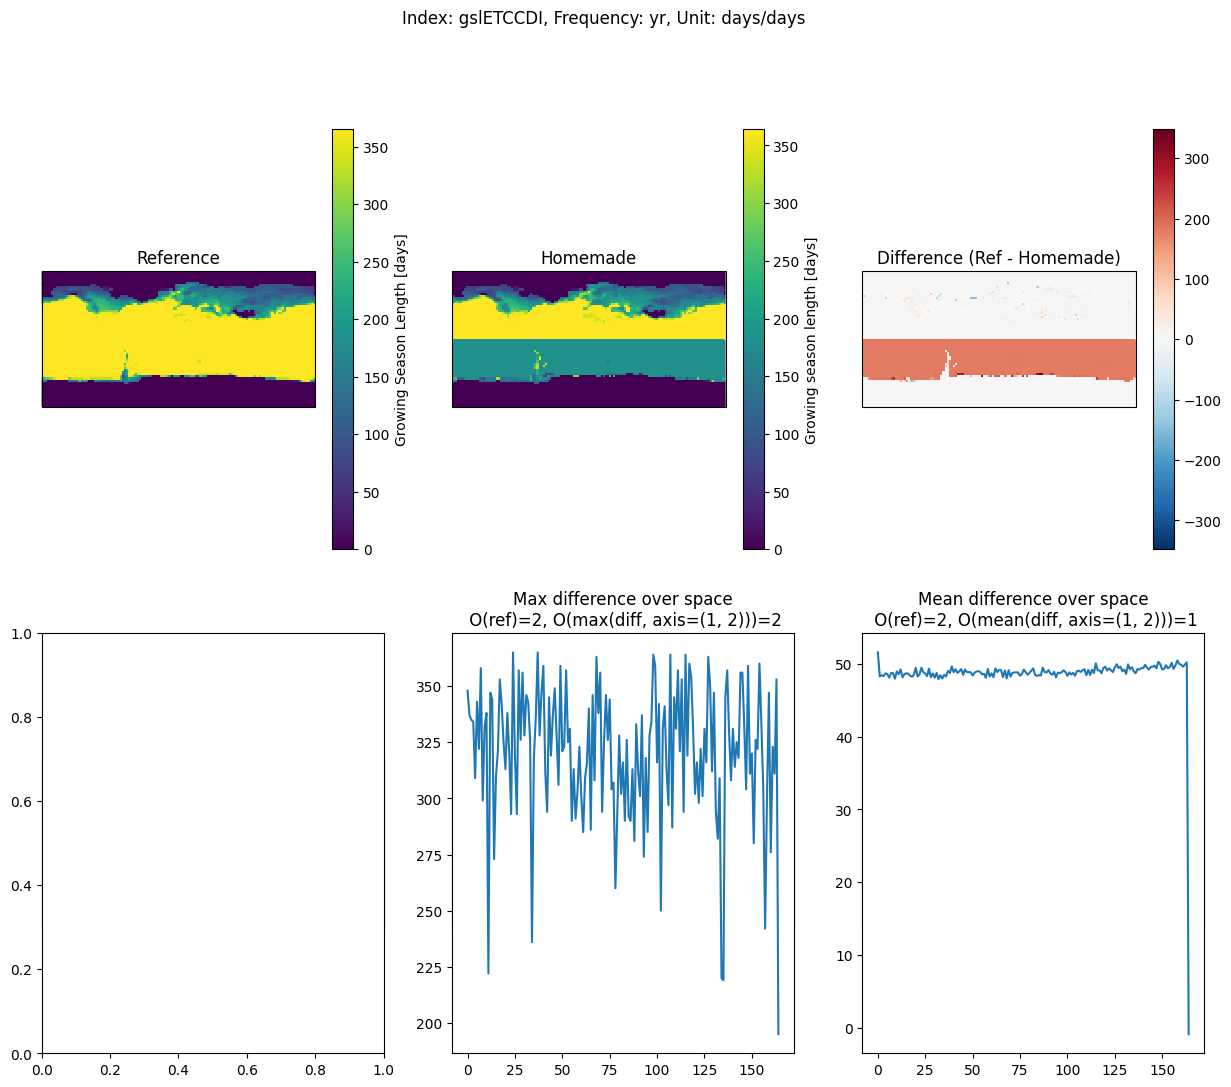

In [ ]:
index_id = 'gslETCCDI'
compute_fq = 'yr'
index_files_homemade =  [file for file in new_files if all(substring in file.name for substring in [index_id, compute_fq,'historical'])]
index_files_ref = list(refdir_path.glob(f'{index_id}_{compute_fq}_*historical*.nc'))
if len(index_files_homemade) != 1 or len(index_files_ref) != 1:
    print(f"Skipping {index_id} at {compute_fq} due to unexpected number of files. Homemade: {len(index_files_homemade)}, ref: {len(index_files_ref)}")
    print("")

print(f'Checking for {index_id}')
homemade_file = index_files_homemade[0]
ref_file = index_files_ref[0]
ref_ds = xr.open_dataset(ref_file, decode_timedelta=False)
homemade_ds = xr.open_dataset(homemade_file, decode_timedelta=False)

# --- check that the dimensions are equal
print(" * Checking dimensions...")
for dim in ref_ds.sizes:
    ref_dim = ref_ds.sizes[dim]
    homemade_dim = homemade_ds.sizes[dim]
    print(f"    * Reference dimension {dim}: {ref_dim}")
    print(f"    * Homemade dimension {dim}: {homemade_dim}")
    assert ref_ds.sizes[dim] == homemade_ds.sizes[dim], f"Dimension {dim} does not match: {ref_ds.sizes[dim]} != {homemade_ds.sizes[dim]}"

# --- check that coordinates are equal
print(" * Checking coordinates...")
for coord in [coord for coord in ref_ds.coords if coord not in ['height']]:
    ref_coord = ref_ds[coord]
    homemade_coord = homemade_ds[coord]

    diff = ref_coord.values - homemade_coord.values
    if diff.dtype == 'float64':
        diff = np.abs(diff)
        assert (diff < 1e-5).all(), f"Coordinate {coord} does not match"
    else:
        import datetime
        assert all(val == datetime.timedelta(0) for val in diff), f"Coordinate {coord} does not match"
    print(f"    * Coordinate {coord} matches.")

# --- plot
fig, axs = plt.subplots(
    2, 3,
    figsize=(15, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
# Replace bottom row with regular (non-projection) axes for line plots
for j in range(3):
    axs[1, j] = fig.add_subplot(2, 3, 4 + j)
homemade_ds[index_id].isel(time=0).plot(ax=axs[0,1])
ref_ds[index_id].isel(time=0).plot(ax=axs[0,0])
diff = ref_ds[index_id].values - homemade_ds[index_id].values
diff_da = xr.DataArray(diff, coords=ref_ds[index_id].coords, dims=ref_ds[index_id].dims)
diff_da.isel(time=0).plot(ax=axs[0,2])

nanmean_diff = np.nanmean(diff, axis=(1, 2))
axs[1, 2].plot(nanmean_diff)
# find the difference in order of magnitude between diff and ref_ds[index_id]
order_of_magnitude_ref = np.floor(np.log10(np.nanmax(np.abs(ref_ds[index_id].values))))
order_of_magnitude_nanmeandiff = np.floor(np.log10(np.nanmax(np.abs(nanmean_diff))))
magnitude_diff = order_of_magnitude_ref - order_of_magnitude_nanmeandiff
axs[1, 2].set_title(f'Mean difference over space\n O(ref)={order_of_magnitude_ref:.0f}, O(mean(diff, axis=(1, 2)))={order_of_magnitude_nanmeandiff:.0f}')

nanmax_diff = np.nanmax(diff, axis=(1, 2))
axs[1, 1].plot(nanmax_diff)
# find the difference in order of magnitude between diff and ref_ds[index_id]
order_of_magnitude_ref = np.floor(np.log10(np.nanmax(np.abs(ref_ds[index_id].values))))
order_of_magnitude_nanmaxdiff = np.floor(np.log10(np.nanmax(np.abs(nanmax_diff))))
magnitude_diff = order_of_magnitude_ref - order_of_magnitude_nanmaxdiff
axs[1, 1].set_title(f'Max difference over space\n O(ref)={order_of_magnitude_ref:.0f}, O(max(diff, axis=(1, 2)))={order_of_magnitude_nanmaxdiff:.0f}')

fig.suptitle(f'Index: {index_id}, Frequency: {compute_fq}, Unit: {ref_ds[index_id].units}/{homemade_ds[index_id].units}')
axs[0, 0].set_title('Reference')
axs[0, 1].set_title('Homemade')
axs[0, 2].set_title('Difference (Ref - Homemade)')
plt.show()
print("")

In [ ]:
import netCDF4
nc = netCDF4.Dataset('/nird/datalake/NS9560K/johannef/test_ETCCDI_calc/homemade_output/gslETCCDI_yr_CanESM5_historical_r1i1p1f1_1850_2014.nc')
# Extract first time slice of variable 'gsl'
temp_slice = nc.variables['gslETCCDI'][0, :, :]
with open('output.txt', 'w') as f:
    for lat in temp_slice:
        f.write(f"{lat}\n")